In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


In [11]:
# ===============================
# Parámetros generales
# ===============================
fs = 1000        # Hz
T = 2            # segundos
t = np.arange(0, T, 1/fs)

# Señal: seno pequeño (simula ECG en escala)
f_sig = 5        # Hz
signal = 1e-3 * np.sin(2 * np.pi * f_sig * t)  # 1 mV

# Rango ADC
Vfs = 6.0        # ±1 V
bits_list = [10, 16]

In [12]:
# ===============================
# Función de cuantización
# ===============================
def quantize(x, bits, Vfs):
    levels = 2**bits
    delta = Vfs / levels
    x_clip = np.clip(x, -Vfs/2, Vfs/2 - delta)
    q = np.round((x_clip + Vfs/2) / delta) * delta - Vfs/2
    return q

# ===============================
# Cuantización
# ===============================
q10 = quantize(signal, 10, Vfs)
q16 = quantize(signal, 16, Vfs)

# Ruido de cuantización
noise_q10 = q10 - signal
noise_q16 = q16 - signal


In [13]:
# ===============================
# PSD (FFT del ruido)
# ===============================
f10, psd_q10 = welch(noise_q10, fs, nperseg=4096)
f16, psd_q16 = welch(noise_q16, fs, nperseg=4096)


/tmp/ipython-input-3826946718.py:4: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 2000, using nperseg = 2000
  f10, psd_q10 = welch(noise_q10, fs, nperseg=4096)
/tmp/ipython-input-3826946718.py:5: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 2000, using nperseg = 2000
  f16, psd_q16 = welch(noise_q16, fs, nperseg=4096)


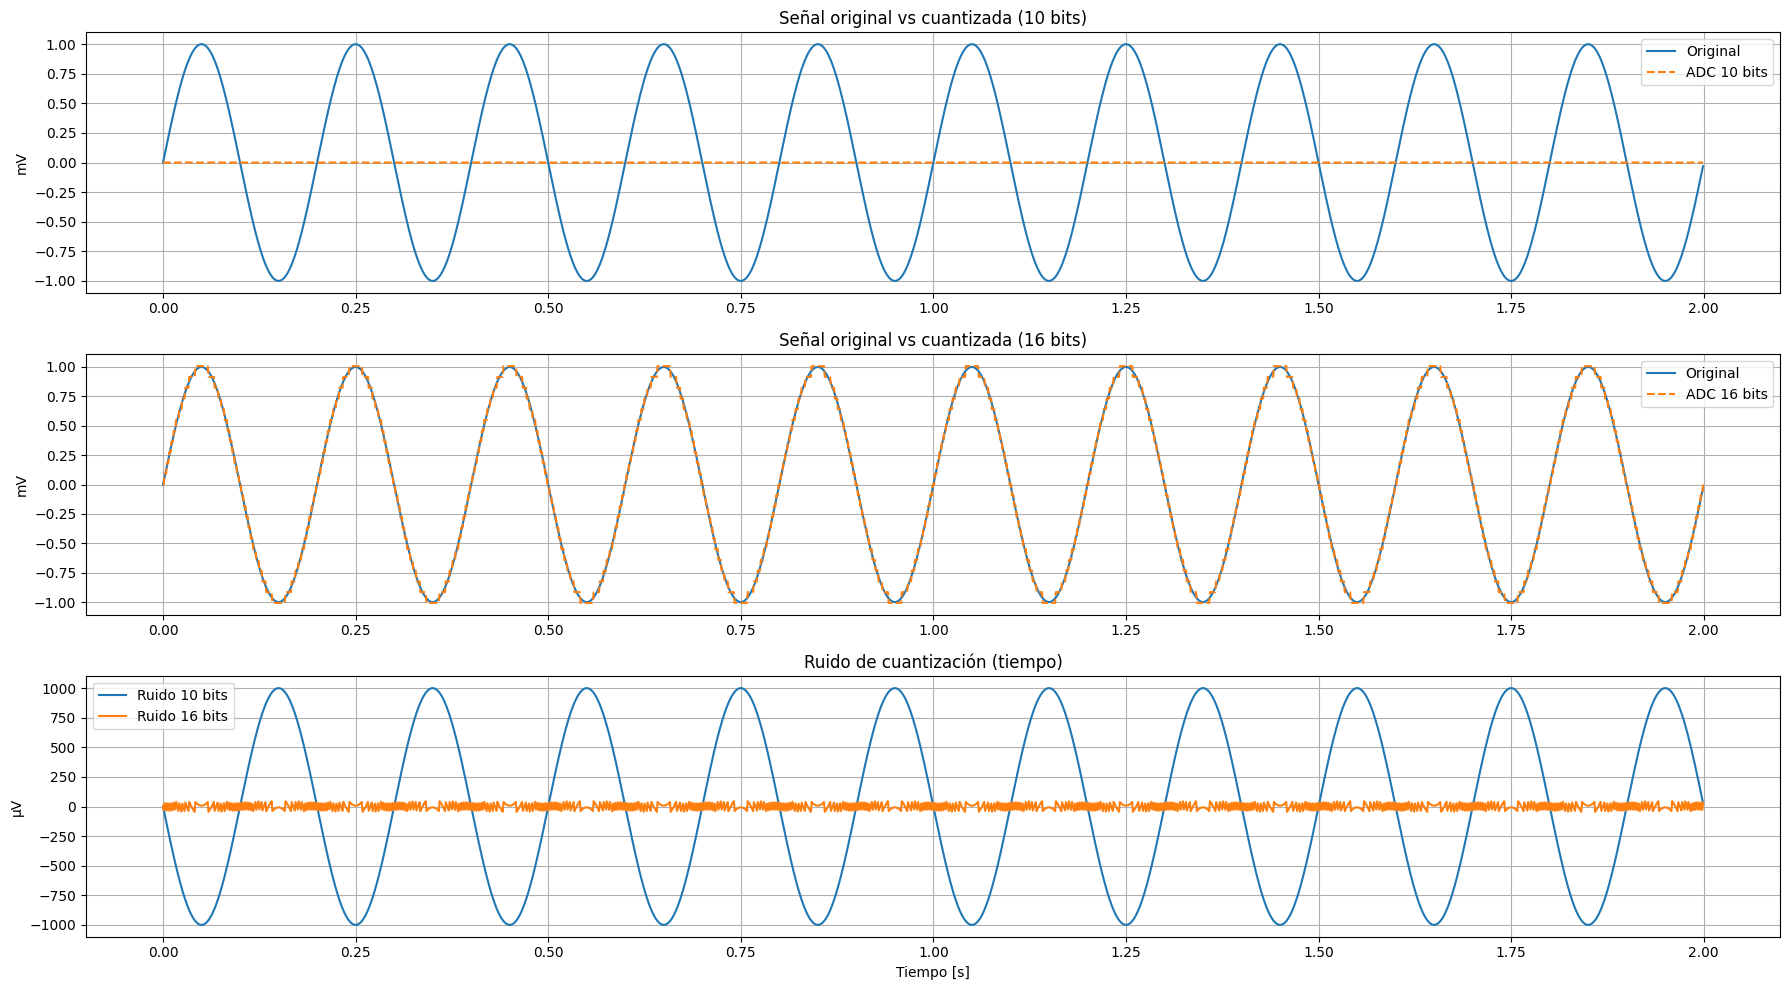

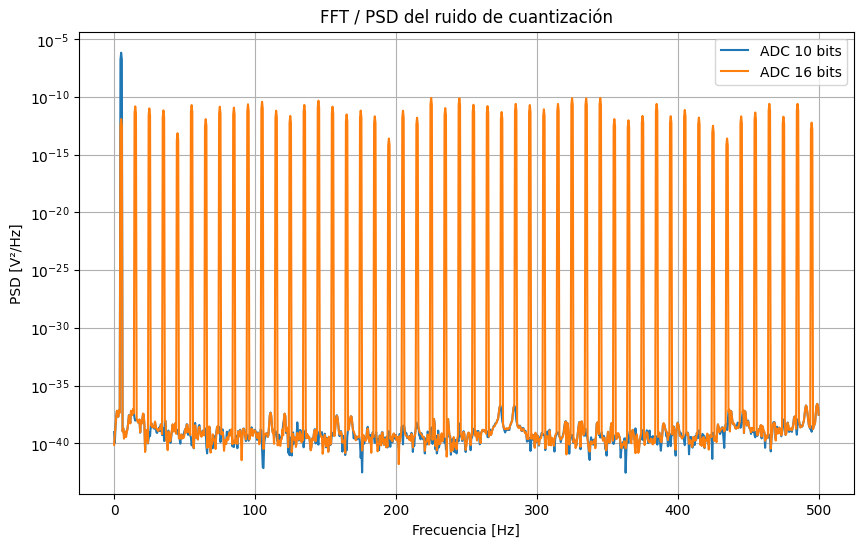

In [14]:
# ===============================
# Gráficas – Dominio del tiempo
# ===============================
plt.figure(figsize=(18, 10))

plt.subplot(3, 1, 1)
plt.plot(t, signal*1e3, label="Original")
plt.plot(t, q10*1e3, '--', label="ADC 10 bits")
plt.title("Señal original vs cuantizada (10 bits)")
plt.ylabel("mV")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, signal*1e3, label="Original")
plt.plot(t, q16*1e3, '--', label="ADC 16 bits")
plt.title("Señal original vs cuantizada (16 bits)")
plt.ylabel("mV")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, noise_q10*1e6, label="Ruido 10 bits")
plt.plot(t, noise_q16*1e6, label="Ruido 16 bits")
plt.title("Ruido de cuantización (tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("µV")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ===============================
# Gráfica – FFT del ruido
# ===============================
plt.figure(figsize=(10, 6))
plt.semilogy(f10, psd_q10, label="ADC 10 bits")
plt.semilogy(f16, psd_q16, label="ADC 16 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.title("FFT / PSD del ruido de cuantización")
plt.legend()
plt.grid(True)
plt.show()